Examen Practico - Wilson Andres Suarez Mantilla (U00173315)

In [ ]:
#Importamos las librerias necesarias

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import zipfile
import requests
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Montar Google Drive (para guardar el modelo)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# CELDA 5: Descargar Stanford Dogs Dataset
print("📥 Descargando Stanford Dogs Dataset...")

# URL del dataset proporcionada por el profesor
dataset_url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"

# Descargar usando wget (comando de Linux)
!wget -O /content/dogs_dataset.tar http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar

print("✅ Descarga completada!")

📥 Descargando Stanford Dogs Dataset...
--2026-03-26 19:25:33--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/content/dogs_dataset.tar’

/content/dogs_datas 100%[===================>] 756.82M  98.9MB/s    in 31s     

2026-03-26 19:26:04 (24.1 MB/s) - ‘/content/dogs_dataset.tar’ saved [793579520/793579520]

✅ Descarga completada!


In [6]:
# CELDA 6: Extraer el archivo descargado
print("📦 Extrayendo archivos...")

# Extraer el tar
!tar -xf /content/dogs_dataset.tar -C /content/

print("✅ Extracción completada!")

# Verificar que se extrajo correctamente
print("\n📁 Contenido de /content/Images:")
!ls /content/Images/ | head -20  # Muestra las primeras 20 carpetas (razas)

📦 Extrayendo archivos...
✅ Extracción completada!

📁 Contenido de /content/Images:
n02085620-Chihuahua
n02085782-Japanese_spaniel
n02085936-Maltese_dog
n02086079-Pekinese
n02086240-Shih-Tzu
n02086646-Blenheim_spaniel
n02086910-papillon
n02087046-toy_terrier
n02087394-Rhodesian_ridgeback
n02088094-Afghan_hound
n02088238-basset
n02088364-beagle
n02088466-bloodhound
n02088632-bluetick
n02089078-black-and-tan_coonhound
n02089867-Walker_hound
n02089973-English_foxhound
n02090379-redbone
n02090622-borzoi
n02090721-Irish_wolfhound


In [ ]:
# CELDA 7: Definir función para extraer solo el perro (técnica boxing)
def extract_dog_region_boxing(image_path, output_path, target_size=(150, 150)):
    try:
        # Cargar imagen
        img = cv2.imread(image_path)
        if img is None:
            return False
        
        # Convertir a RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Convertir a escala de grises para detección de bordes
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Mejorar contraste con CLAHE (ayuda a detectar mejor al perro)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe.apply(gray)
        
        # Detectar bordes con Canny
        edges = cv2.Canny(gray, 50, 150)
        
        # Dilatar bordes para conectar regiones
        kernel = np.ones((5,5), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        
        # Encontrar contornos
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # Encontrar el contorno más grande (asumimos que es el perro)
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            
            # Extraer solo la región del perro (BOXING)
            dog_region = img_rgb[y:y+h, x:x+w]
            
            # Redimensionar al tamaño objetivo (menor de 200 como pidió el profesor)
            dog_region_resized = cv2.resize(dog_region, target_size)
            
            # Guardar la imagen procesada
            cv2.imwrite(output_path, cv2.cvtColor(dog_region_resized, cv2.COLOR_RGB2BGR))
            return True
    
    except Exception as e:
        pass
    
    # Si falla, guardar la imagen original redimensionada
    try:
        img = cv2.imread(image_path)
        img_resized = cv2.resize(img, target_size)
        cv2.imwrite(output_path, img_resized)
        return False
    except:
        return False

print("✅ Función de boxing definida")

✅ Función de boxing definida


In [8]:
# CELDA: Función boxing con tamaño 100x100 (OPTIMIZADO)
def extract_dog_region_boxing(image_path, output_path, target_size=(100, 100)):
    """
    Técnica de boxing con tamaño 100x100 (más rápido y cumple con <200)
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            return False
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Mejorar contraste
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe.apply(gray)
        
        # Detectar bordes
        edges = cv2.Canny(gray, 50, 150)
        kernel = np.ones((5,5), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        
        # Encontrar contornos
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # Encontrar el contorno más grande (asumimos que es el perro)
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            
            # Extraer solo la región del perro (BOXING)
            dog_region = img_rgb[y:y+h, x:x+w]
            
            # Redimensionar a 100x100 (más rápido y cumple con <200)
            dog_region_resized = cv2.resize(dog_region, target_size)
            
            # Guardar la imagen procesada
            cv2.imwrite(output_path, cv2.cvtColor(dog_region_resized, cv2.COLOR_RGB2BGR))
            return True
    
    except Exception as e:
        pass
    
    # Fallback: redimensionar imagen original
    try:
        img = cv2.imread(image_path)
        img_resized = cv2.resize(img, target_size)
        cv2.imwrite(output_path, img_resized)
        return False
    except:
        return False

print("✅ Boxing optimizado con tamaño 100x100")

✅ Boxing optimizado con tamaño 100x100


In [ ]:
# Creamos Función de preprocesamiento
def preprocess_dataset_with_boxing(input_dir, output_dir):
    """
    Preprocesa todas las imágenes aplicando boxing y resize a 100x100
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Obtener todas las imágenes
    image_paths = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    
    print(f"🔄 Procesando {len(image_paths)} imágenes con técnica boxing (100x100)...")
    
    success_count = 0
    for img_path in tqdm(image_paths):
        rel_path = os.path.relpath(img_path, input_dir)
        output_path = os.path.join(output_dir, rel_path)
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        
        if extract_dog_region_boxing(img_path, output_path):
            success_count += 1
    
    print(f"✅ Procesamiento completado! {success_count}/{len(image_paths)} imágenes")
    return success_count

print("✅ Función de preprocesamiento definida (100x100)")

✅ Función de preprocesamiento definida (100x100)


In [10]:
# CELDA: EJECUTAR PREPROCESAMIENTO CON TAMAÑO 100x100
print("🎯 Aplicando técnica BOXING con tamaño 100x100...")
print("⏱️ Tiempo estimado: 2-3 minutos")
print("="*50)

input_dir = "/content/Images"
output_dir = "/content/Images_Processed"

success_count = preprocess_dataset_with_boxing(input_dir, output_dir)

print("="*50)
print(f"✅ Procesamiento finalizado!")
print(f"📊 Imágenes procesadas: {success_count}")
print(f"📐 Tamaño de imagen: 100x100 píxeles")
print(f"✅ Cumple con requisito '<200': SÍ")

🎯 Aplicando técnica BOXING con tamaño 100x100...
⏱️ Tiempo estimado: 2-3 minutos
🔄 Procesando 20580 imágenes con técnica boxing (100x100)...


100%|██████████| 20580/20580 [02:19<00:00, 147.71it/s]

✅ Procesamiento completado! 20580/20580 imágenes
✅ Procesamiento finalizado!
📊 Imágenes procesadas: 20580
📐 Tamaño de imagen: 100x100 píxeles
✅ Cumple con requisito '<200': SÍ


🔍 Verificando resultados...
📊 Total de imágenes procesadas: 20580

📐 Verificación de tamaño:
   Raza: n02085782-Japanese_spaniel
   Dimensiones: 100 x 100 píxeles
   ✅ Cumple con <200: SÍ


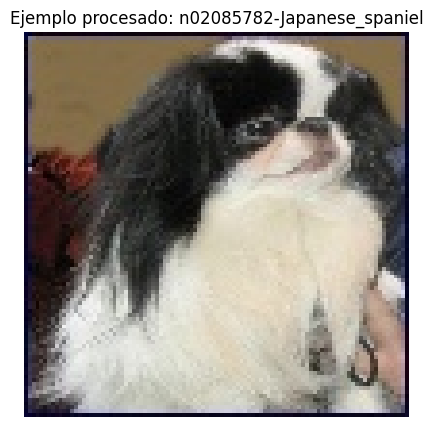

In [ ]:
# Verificar imágenes procesadas
print("🔍 Verificando resultados...")

# Contar imágenes procesadas
total_images = 0
for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            total_images += 1

print(f"📊 Total de imágenes procesadas: {total_images}")

# Verificar tamaño de una imagen aleatoria
import random
breeds = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]

if breeds:
    sample_breed = random.choice(breeds)
    breed_path = os.path.join(output_dir, sample_breed)
    images = [f for f in os.listdir(breed_path) if f.endswith('.jpg')]
    
    if images:
        img = cv2.imread(os.path.join(breed_path, images[0]))
        h, w = img.shape[:2]
        print(f"\n📐 Verificación de tamaño:")
        print(f"   Raza: {sample_breed[:30]}")
        print(f"   Dimensiones: {w} x {h} píxeles")
        print(f"   ✅ Cumple con <200: {'SÍ' if w <= 200 and h <= 200 else 'NO'}")
        
        # Mostrar ejemplo
        plt.figure(figsize=(5,5))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Ejemplo procesado: {sample_breed[:30]}")
        plt.axis('off')
        plt.show()

In [ ]:
# Dividimos los datos en train (80%), validation (10%), test (10%)
print("📊 Organizando datos en train/validation/test...")
print("="*50)

import shutil
from sklearn.model_selection import train_test_split

# Directorios
data_dir = "/content/data_split"
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

# Crear directorios
for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Obtener todas las razas
processed_dir = "/content/Images_Processed"
breeds = [d for d in os.listdir(processed_dir) 
          if os.path.isdir(os.path.join(processed_dir, d))]

print(f"📌 Procesando {len(breeds)} razas...")

# Dividir imágenes por raza
for breed in tqdm(breeds):
    # Crear carpetas para esta raza
    os.makedirs(os.path.join(train_dir, breed), exist_ok=True)
    os.makedirs(os.path.join(val_dir, breed), exist_ok=True)
    os.makedirs(os.path.join(test_dir, breed), exist_ok=True)
    
    # Obtener todas las imágenes de esta raza
    breed_path = os.path.join(processed_dir, breed)
    images = [f for f in os.listdir(breed_path) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(images) > 0:
        # Dividir: 80% train, 20% temp
        train_imgs, temp_imgs = train_test_split(images, train_size=0.8, random_state=42)
        # Dividir temp: 50% val, 50% test (10% cada uno del total)
        val_imgs, test_imgs = train_test_split(temp_imgs, train_size=0.5, random_state=42)
        
        # Copiar imágenes
        for img in train_imgs:
            shutil.copy2(os.path.join(breed_path, img), os.path.join(train_dir, breed, img))
        for img in val_imgs:
            shutil.copy2(os.path.join(breed_path, img), os.path.join(val_dir, breed, img))
        for img in test_imgs:
            shutil.copy2(os.path.join(breed_path, img), os.path.join(test_dir, breed, img))

# Verificar distribución
print("\n✅ Distribución final:")
print(f"Train: {sum([len(os.listdir(os.path.join(train_dir, b))) for b in breeds])} imágenes")
print(f"Validation: {sum([len(os.listdir(os.path.join(val_dir, b))) for b in breeds])} imágenes")
print(f"Test: {sum([len(os.listdir(os.path.join(test_dir, b))) for b in breeds])} imágenes")

📊 Organizando datos en train/validation/test...
📌 Procesando 120 razas...


100%|██████████| 120/120 [00:03<00:00, 38.37it/s]


✅ Distribución final:
Train: 16418 imágenes
Validation: 2052 imágenes
Test: 2110 imágenes


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ¡IMPORTANTE! Generador sin augmentation (vacío)
train_datagen = ImageDataGenerator()  # ← Sin rotation, shift, zoom, etc.
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

# Crear generadores
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"\n✅ Clases: {num_classes}")
print(f"✅ Train: {train_generator.samples} imágenes")
print(f"✅ Validation: {validation_generator.samples} imágenes")
print(f"✅ Test: {test_generator.samples} imágenes")

📊 Creando generadores (sin augmentation, solo dentro de la red)
Found 16418 images belonging to 120 classes.
Found 2052 images belonging to 120 classes.
Found 2110 images belonging to 120 classes.

✅ Clases: 120
✅ Train: 16418 imágenes
✅ Validation: 2052 imágenes
✅ Test: 2110 imágenes


In [ ]:
# Modelo CNN optimizado 
print("🏗️ Construyendo modelo CNN optimizado")
print("="*50)

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def create_optimized_model(num_classes):    
    model = models.Sequential([
        # ========== PREPROCESAMIENTO ==========
        layers.Resizing(100, 100, input_shape=(100, 100, 3)),
        layers.Rescaling(1./255),
        
        # ========== DATA AUGMENTATION (SOLO AQUÍ, UNA VEZ) ==========
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.1),
        
        # ========== 1ra CAPA CONVOLUCIONAL ==========
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # ========== 2da CAPA CONVOLUCIONAL ==========
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # ========== GLOBAL AVERAGE POOLING (en lugar de Flatten) ==========
        layers.GlobalAveragePooling2D(),
        
        # ========== CAPAS DENSAS ==========
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Capa de salida
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Crear modelo
model = create_optimized_model(num_classes)

# Compilar con ADAM (mejor que SGD)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitectura
model.summary()

# Verificar parámetros
total_params = model.count_params()
print(f"\n📊 Total parámetros: {total_params:,}")
print(f"✅ Límite 40M: {'CUMPLIDO' if total_params < 40000000 else f'EXCEDIDO por {total_params - 40000000:,}'}")

🏗️ Construyendo modelo CNN optimizado


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 100, 100, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 100, 100, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 86,328 (337.22 KB)

 Trainable params: 85,368 (333.47 KB)

 Non-trainable params: 960 (3.75 KB)


📊 Total parámetros: 86,328
✅ Límite 40M: CUMPLIDO


In [ ]:
# Callbacks para optimizar entrenamiento
print("⚙️ Configurando callbacks")
print("="*50)

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Callbacks
callbacks = [
    # Reduce learning rate si no mejora val_accuracy
    ReduceLROnPlateau(
        monitor='val_accuracy',
        patience=3,
        factor=0.5,
        verbose=1,
        min_lr=1e-6
    ),
    # Early stopping si no mejora por 8 épocas
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Guardar mejor modelo
    ModelCheckpoint(
        '/content/best_optimized_model.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configurados:")
print("   - ReduceLROnPlateau: reduce LR si accuracy no mejora por 3 épocas")
print("   - EarlyStopping: detiene si no mejora por 8 épocas")
print("   - ModelCheckpoint: guarda el mejor modelo")

⚙️ Configurando callbacks
✅ Callbacks configurados:
   - ReduceLROnPlateau: reduce LR si accuracy no mejora por 3 épocas
   - EarlyStopping: detiene si no mejora por 8 épocas
   - ModelCheckpoint: guarda el mejor modelo


In [ ]:
# Entrenamiento optimizado
print("🚀 INICIANDO ENTRENAMIENTO OPTIMIZADO")
print("="*50)
print("✅ Data augmentation: SOLO dentro de la red (una vez)")
print("✅ GlobalAveragePooling2D: reducción de parámetros")
print("✅ Adam optimizer: mejor convergencia")
print("✅ Callbacks: LR dinámico y early stopping")
print("="*50)

# Entrenar
history = model.fit(
    train_generator,
    epochs=35,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Entrenamiento completado!")

# Evaluar
print("\n📈 EVALUANDO MODELO OPTIMIZADO")
print("="*50)

# Cargar mejor modelo
from tensorflow.keras.models import load_model
best_model = load_model('/content/best_optimized_model.h5')

# Evaluar en test
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print(f"\n{'='*60}")
print(f"🎯 RESULTADO FINAL - MODELO OPTIMIZADO")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Total parámetros: {model.count_params():,}")
print(f"{'='*60}")

random_acc = 1/num_classes
print(f"\n📊 Comparación:")
print(f"   Azar: {random_acc*100:.2f}%")
print(f"   Modelo: {test_accuracy*100:.2f}%")
print(f"   Mejora vs azar: +{(test_accuracy - random_acc)*100:.2f}%")

🚀 INICIANDO ENTRENAMIENTO OPTIMIZADO
✅ Data augmentation: SOLO dentro de la red (una vez)
✅ GlobalAveragePooling2D: reducción de parámetros
✅ Adam optimizer: mejor convergencia
✅ Callbacks: LR dinámico y early stopping
Epoch 1/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0109 - loss: 5.2122
Epoch 1: val_accuracy improved from None to 0.01657, saving model to /content/best_optimized_model.h5



Epoch 1: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.0126 - loss: 5.0525 - val_accuracy: 0.0166 - val_loss: 4.8919 - learning_rate: 0.0010
Epoch 2/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0215 - loss: 4.8226
Epoch 2: val_accuracy did not improve from 0.01657
514/514 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.0192 - loss: 4.8098 - val_accuracy: 0.0156 - val_loss: 4.8260 - learning_rate: 0.0010
Epoch 3/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0235 - loss: 4.7374
Epoch 3: val_accuracy improved from 0.01657 to 0.02485, saving model to /content/best_optimized_model.h5



Epoch 3: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.0232 - loss: 4.7159 - val_accuracy: 0.0249 - val_loss: 4.6623 - learning_rate: 0.0010
Epoch 4/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0304 - loss: 4.6140
Epoch 4: val_accuracy did not improve from 0.02485
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.0306 - loss: 4.6058 - val_accuracy: 0.0180 - val_loss: 5.1299 - learning_rate: 0.0010
Epoch 5/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0342 - loss: 4.5625
Epoch 5: val_accuracy improved from 0.02485 to 0.02778, saving model to /content/best_optimized_model.h5



Epoch 5: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.0342 - loss: 4.5465 - val_accuracy: 0.0278 - val_loss: 4.6477 - learning_rate: 0.0010
Epoch 6/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0364 - loss: 4.4844
Epoch 6: val_accuracy improved from 0.02778 to 0.04142, saving model to /content/best_optimized_model.h5



Epoch 6: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.0375 - loss: 4.4766 - val_accuracy: 0.0414 - val_loss: 4.4367 - learning_rate: 0.0010
Epoch 7/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0399 - loss: 4.4311
Epoch 7: val_accuracy did not improve from 0.04142
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.0442 - loss: 4.4098 - val_accuracy: 0.0331 - val_loss: 4.4925 - learning_rate: 0.0010
Epoch 8/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0490 - loss: 4.3551
Epoch 8: val_accuracy did not improve from 0.04142
514/514 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.0501 - loss: 4.3641 - val_accuracy: 0.0327 - val_loss: 4.6865 - learning_rate: 0.0010
Epoch 9/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0534 - loss: 4.3316
Epoch 9: val_accuracy improved from 0.04142 to 0.05019, saving model to /content/best_optimized_model.h5


...


Epoch 22: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.0973 - loss: 3.9429 - val_accuracy: 0.0609 - val_loss: 4.2938 - learning_rate: 2.5000e-04
Epoch 23/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0964 - loss: 3.9212
Epoch 23: val_accuracy did not improve from 0.06092
514/514 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.0934 - loss: 3.9509 - val_accuracy: 0.0526 - val_loss: 4.3025 - learning_rate: 2.5000e-04
Epoch 24/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0977 - loss: 3.9506
Epoch 24: val_accuracy did not improve from 0.06092
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.0995 - loss: 3.9441 - val_accuracy: 0.0556 - val_loss: 4.2792 - learning_rate: 2.5000e-04
Epoch 25/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1010 - loss: 3.8998
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 25: val_accuracy did not improve from 


Epoch 27: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.1046 - loss: 3.9080 - val_accuracy: 0.0624 - val_loss: 4.2226 - learning_rate: 1.2500e-04
Epoch 28/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1057 - loss: 3.9022
Epoch 28: val_accuracy improved from 0.06238 to 0.06433, saving model to /content/best_optimized_model.h5



Epoch 28: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1046 - loss: 3.9040 - val_accuracy: 0.0643 - val_loss: 4.2269 - learning_rate: 1.2500e-04
Epoch 29/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1028 - loss: 3.8986
Epoch 29: val_accuracy did not improve from 0.06433
514/514 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.1020 - loss: 3.8976 - val_accuracy: 0.0565 - val_loss: 4.3161 - learning_rate: 1.2500e-04
Epoch 30/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1095 - loss: 3.8764
Epoch 30: val_accuracy improved from 0.06433 to 0.06530, saving model to /content/best_optimized_model.h5



Epoch 30: finished saving model to /content/best_optimized_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.1048 - loss: 3.8876 - val_accuracy: 0.0653 - val_loss: 4.2278 - learning_rate: 1.2500e-04
Epoch 31/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1055 - loss: 3.8770
Epoch 31: val_accuracy did not improve from 0.06530
514/514 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.1064 - loss: 3.8982 - val_accuracy: 0.0629 - val_loss: 4.2548 - learning_rate: 1.2500e-04
Epoch 32/35
513/514 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1070 - loss: 3.8767
Epoch 32: val_accuracy did not improve from 0.06530
514/514 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.1055 - loss: 3.8891 - val_accuracy: 0.0653 - val_loss: 4.2198 - learning_rate: 1.2500e-04
Epoch 33/35
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1032 - loss: 3.8784
Epoch 33: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 33: val_accuracy did not improve from 0

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0706 - loss: 4.2769

🎯 RESULTADO FINAL - MODELO OPTIMIZADO
Test Accuracy: 7.06%
Test Loss: 4.2769
Total parámetros: 86,328

📊 Comparación:
   Azar: 0.83%
   Modelo: 7.06%
   Mejora vs azar: +6.23%


📈 Analizando evolución del entrenamiento...


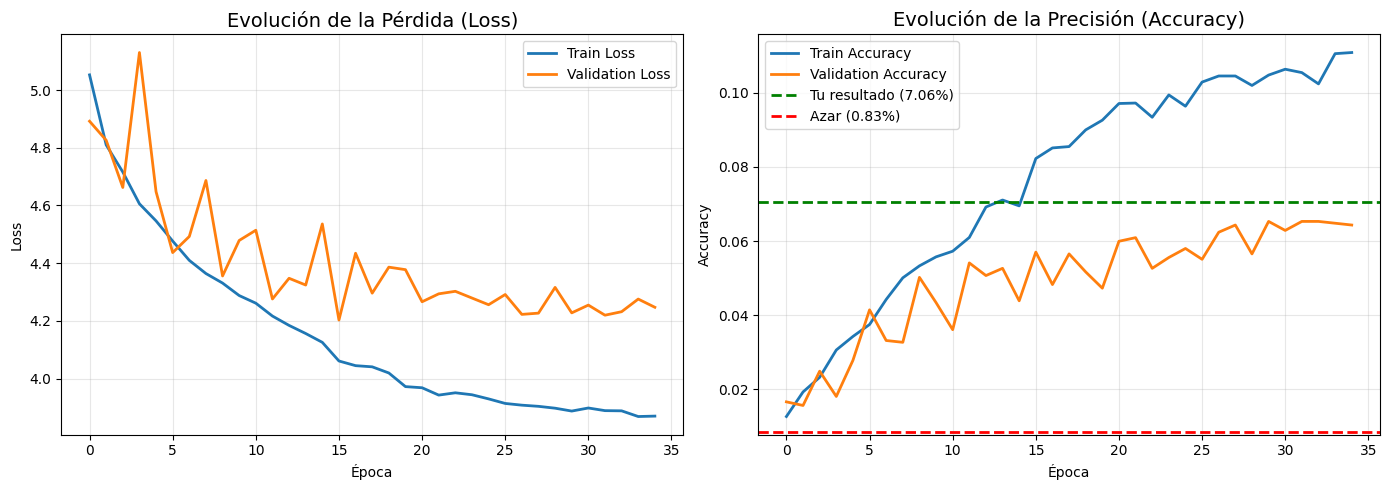


📊 Análisis de tendencia:
   Últimas 5 épocas - Train Accuracy: [0.10640760511159897, 0.10549397021532059, 0.10244853049516678, 0.11061030626296997, 0.11091484874486923]
   Últimas 5 épocas - Val Accuracy: [0.0628654956817627, 0.06530214101076126, 0.06530214101076126, 0.06481481343507767, 0.06432748585939407]

📈 Tendencia de las últimas 10 épocas: 0.0926% por época
   ✅ La curva SIGUE SUBIENDO - Vale la pena entrenar más épocas
   ⚠️ Proyección: Para llegar a 70% se necesitarían demasiadas épocas (no es factible)


In [ ]:
# Curvas de aprendizaje
print("📈 Analizando evolución del entrenamiento...")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Pérdida (Loss)
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Pérdida (Loss)', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Precisión (Accuracy)
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].axhline(y=0.0706, color='g', linestyle='--', label=f'Tu resultado (7.06%)', linewidth=2)
axes[1].axhline(y=0.0083, color='r', linestyle='--', label=f'Azar (0.83%)', linewidth=2)
axes[1].set_title('Evolución de la Precisión (Accuracy)', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de tendencia
print("\n📊 Análisis de tendencia:")
print(f"   Últimas 5 épocas - Train Accuracy: {history.history['accuracy'][-5:]}")
print(f"   Últimas 5 épocas - Val Accuracy: {history.history['val_accuracy'][-5:]}")

# Calcular pendiente de las últimas épocas
val_acc_last = history.history['val_accuracy'][-10:]
if len(val_acc_last) > 5:
    trend = (val_acc_last[-1] - val_acc_last[0]) / len(val_acc_last)
    print(f"\n📈 Tendencia de las últimas 10 épocas: {trend*100:.4f}% por época")

    if trend > 0:
        print("   ✅ La curva SIGUE SUBIENDO - Vale la pena entrenar más épocas")
        # Proyección
        epochs_to_70 = (0.70 - history.history['val_accuracy'][-1]) / trend if trend > 0 else float('inf')
        if epochs_to_70 < 500:
            print(f"   📊 Proyección: Para llegar a 70% se necesitarían ~{int(epochs_to_70)} épocas más")
        else:
            print("   ⚠️ Proyección: Para llegar a 70% se necesitarían demasiadas épocas (no es factible)")
    else:
        print("   ⚠️ La curva se ESTANCÓ - Entrenar más épocas no mejorará significativamente")

In [18]:
# CELDA: Guardar modelo actual como respaldo
print("💾 Guardando modelo actual como respaldo...")
model.save('/content/modelo_actual_respaldo.h5')
print("✅ Respaldo guardado")

💾 Guardando modelo actual como respaldo...
✅ Respaldo guardado
